In [15]:
# Import all required libraries
import pandas as pd
import numpy as np
import pingouin as pg
from pathlib import Path
from scipy import stats
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import os.path as op
import re

In [16]:
# Setup directories and plotting theme
ANNOT_DIR = Path("dset/derivatives/annotations")
OUT_DIR = Path("dset/derivatives/caps/interrater")
FIGURES_DIR = Path("dset/derivatives/figures")

# Create directories
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Configure plotting theme
sns.set_theme(style="darkgrid")

# Define colors for consistent plotting
colors = ['#CF9397', "#606933", '#E5D28E', '#715958', '#AC9B74', '#8c564b', '#e377c2', '#BCB5BB']

In [17]:
# Inter-Rater Reliability Analysis: ICC + Spearman Correlation (3 Raters)
print("Calculating Inter-Rater Reliability: ICC + Spearman Correlation")

# Find all rater annotation files
rater_files = sorted(list(ANNOT_DIR.glob("*.csv")))
print(f"Found {len(rater_files)} rater files:")
for rf in rater_files:
    print(f"  - {rf.name}")

if len(rater_files) < 2:
    print("ERROR: Need at least 2 rater files for inter-rater reliability analysis")
else:
    # Load all rater files
    rater_dfs = []
    rater_names = []
    
    for i, rater_file in enumerate(rater_files):
        # Extract rater name from filename (e.g., "S01E01R01(Kayanna).csv" -> "Kayanna")
        rater_name = rater_file.stem.split('(')[1].rstrip(')')
        rater_names.append(rater_name)
        
        df = pd.read_csv(rater_file)
        df = df.rename(columns={
            'valence': f'valence_{rater_name}',
            'arousal': f'arousal_{rater_name}'
        })
        rater_dfs.append(df[['index', f'valence_{rater_name}', f'arousal_{rater_name}']])
    
    # Merge all raters on 'index'
    merged_df = rater_dfs[0]
    for df in rater_dfs[1:]:
        merged_df = merged_df.merge(df, on='index', how='outer')
    
    print(f"\nMerged data shape (before filtering): {merged_df.shape}")
    
    # Extract episode and run info from index
    # Pattern: S01E01R01_clip0000 -> episode=1, run=1, clip=0
    merged_df['episode'] = merged_df['index'].str.extract(r'S\d+E(\d+)').astype(int)
    merged_df['run_number'] = merged_df['index'].str.extract(r'R(\d+)').astype(int)
    merged_df['clip_number'] = merged_df['index'].str.extract(r'clip(\d+)').astype(int)
    
    # FILTER: Only include clips up to clip0150
    print(f"\n⚠️  FILTERING: Only including clips up to S01E01R01_clip0150")
    merged_df = merged_df[merged_df['clip_number'] <= 150].copy()
    print(f"Filtered data shape: {merged_df.shape}")
    print(f"Clip number range: {merged_df['clip_number'].min()} to {merged_df['clip_number'].max()}")
    
    print(f"Raters: {rater_names}")
    
    # Create target ID for ICC
    merged_df['target_id'] = merged_df['index']
    
    # Results storage
    overall_results = []
    run_results = []
    
    # Get unique episodes
    unique_episodes = sorted(merged_df['episode'].dropna().unique())
    
    # ===== OVERALL ANALYSIS (ALL DATA COMBINED) =====
    print("\n" + "="*60)
    print("OVERALL ANALYSIS (All Episodes & Runs)")
    print("="*60)
    
    valence_cols = [f'valence_{name}' for name in rater_names]
    arousal_cols = [f'arousal_{name}' for name in rater_names]
    
    # Prepare valence data for ICC
    valence_long = merged_df.melt(
        id_vars=['target_id'], value_vars=valence_cols,
        var_name='rater', value_name='valence'
    )
    valence_long['rater'] = valence_long['rater'].str.replace('valence_', '')
    valence_long['valence'] = pd.to_numeric(valence_long['valence'], errors='coerce')
    valence_long = valence_long.dropna()
    
    # Calculate overall ICC for valence
    val_icc = val_ci_lower = val_ci_upper = val_icc_p = None
    try:
        if len(valence_long) > 0:
            icc_result = pg.intraclass_corr(data=valence_long, targets='target_id', 
                                          raters='rater', ratings='valence', nan_policy='omit')
            icc2_val = icc_result[icc_result['Type'] == 'ICC2'].iloc[0]
            val_icc = icc2_val['ICC']
            val_ci_lower = icc2_val['CI95%'][0]
            val_ci_upper = icc2_val['CI95%'][1]
            val_icc_p = icc2_val['pval']
            print(f"Valence ICC2: {val_icc:.4f} (95% CI: [{val_ci_lower:.4f}, {val_ci_upper:.4f}]), p={val_icc_p:.4f}")
    except Exception as e:
        print(f"Error calculating valence ICC: {e}")
    
    # Calculate pairwise Spearman for valence (average across all pairs)
    val_spearman_list = []
    for i in range(len(valence_cols)):
        for j in range(i+1, len(valence_cols)):
            try:
                val1 = pd.to_numeric(merged_df[valence_cols[i]], errors='coerce')
                val2 = pd.to_numeric(merged_df[valence_cols[j]], errors='coerce')
                common_idx = val1.dropna().index.intersection(val2.dropna().index)
                if len(common_idx) > 2:
                    r, p = spearmanr(val1.loc[common_idx], val2.loc[common_idx])
                    val_spearman_list.append((r, p))
            except: pass
    
    val_spearman_mean = np.mean([r for r, p in val_spearman_list]) if val_spearman_list else None
    val_spearman_p_mean = np.mean([p for r, p in val_spearman_list]) if val_spearman_list else None
    if val_spearman_mean:
        print(f"Valence Spearman (mean of pairs): ρ={val_spearman_mean:.4f}, p={val_spearman_p_mean:.4f}")
    
    # Prepare arousal data for ICC
    arousal_long = merged_df.melt(
        id_vars=['target_id'], value_vars=arousal_cols,
        var_name='rater', value_name='arousal'
    )
    arousal_long['rater'] = arousal_long['rater'].str.replace('arousal_', '')
    arousal_long['arousal'] = pd.to_numeric(arousal_long['arousal'], errors='coerce')
    arousal_long = arousal_long.dropna()
    
    # Calculate overall ICC for arousal
    aro_icc = aro_ci_lower = aro_ci_upper = aro_icc_p = None
    try:
        if len(arousal_long) > 0:
            icc_result = pg.intraclass_corr(data=arousal_long, targets='target_id', 
                                          raters='rater', ratings='arousal', nan_policy='omit')
            icc2_aro = icc_result[icc_result['Type'] == 'ICC2'].iloc[0]
            aro_icc = icc2_aro['ICC']
            aro_ci_lower = icc2_aro['CI95%'][0]
            aro_ci_upper = icc2_aro['CI95%'][1]
            aro_icc_p = icc2_aro['pval']
            print(f"Arousal ICC2: {aro_icc:.4f} (95% CI: [{aro_ci_lower:.4f}, {aro_ci_upper:.4f}]), p={aro_icc_p:.4f}")
    except Exception as e:
        print(f"Error calculating arousal ICC: {e}")
    
    # Calculate pairwise Spearman for arousal (average across all pairs)
    aro_spearman_list = []
    for i in range(len(arousal_cols)):
        for j in range(i+1, len(arousal_cols)):
            try:
                aro1 = pd.to_numeric(merged_df[arousal_cols[i]], errors='coerce')
                aro2 = pd.to_numeric(merged_df[arousal_cols[j]], errors='coerce')
                common_idx = aro1.dropna().index.intersection(aro2.dropna().index)
                if len(common_idx) > 2:
                    r, p = spearmanr(aro1.loc[common_idx], aro2.loc[common_idx])
                    aro_spearman_list.append((r, p))
            except: pass
    
    aro_spearman_mean = np.mean([r for r, p in aro_spearman_list]) if aro_spearman_list else None
    aro_spearman_p_mean = np.mean([p for r, p in aro_spearman_list]) if aro_spearman_list else None
    if aro_spearman_mean:
        print(f"Arousal Spearman (mean of pairs): ρ={aro_spearman_mean:.4f}, p={aro_spearman_p_mean:.4f}")
    
    # Store overall results
    overall_results.append({
        'Episode': 'All',
        'Run': 'All',
        'N_clips': len(merged_df),
        'N_raters': len(rater_names),
        'Valence_ICC': val_icc,
        'Valence_ICC_CI_Lower': val_ci_lower,
        'Valence_ICC_CI_Upper': val_ci_upper,
        'Valence_ICC_pval': val_icc_p,
        'Valence_Spearman_r': val_spearman_mean,
        'Valence_Spearman_pval': val_spearman_p_mean,
        'Arousal_ICC': aro_icc,
        'Arousal_ICC_CI_Lower': aro_ci_lower,
        'Arousal_ICC_CI_Upper': aro_ci_upper,
        'Arousal_ICC_pval': aro_icc_p,
        'Arousal_Spearman_r': aro_spearman_mean,
        'Arousal_Spearman_pval': aro_spearman_p_mean
    })
    
    # ===== BY RUN ANALYSIS =====
    print("\n" + "="*60)
    print("BY RUN ANALYSIS")
    print("="*60)
    
    # Get unique episode-run combinations
    run_groups = merged_df.groupby(['episode', 'run_number'])
    
    for (ep_num, run_num), run_data in run_groups:
        print(f"\nEpisode {ep_num}, Run {run_num}: {len(run_data)} clips")
        
        run_result = {
            'Episode': ep_num, 'Run': run_num, 'N_clips': len(run_data), 'N_raters': len(rater_names),
            'Valence_ICC': None, 'Valence_ICC_CI_Lower': None, 'Valence_ICC_CI_Upper': None, 'Valence_ICC_pval': None,
            'Valence_Spearman_r': None, 'Valence_Spearman_pval': None,
            'Arousal_ICC': None, 'Arousal_ICC_CI_Lower': None, 'Arousal_ICC_CI_Upper': None, 'Arousal_ICC_pval': None,
            'Arousal_Spearman_r': None, 'Arousal_Spearman_pval': None
        }
        
        # Valence analysis for this run
        try:
            valence_long_run = run_data.melt(id_vars=['target_id'], value_vars=valence_cols,
                                           var_name='rater', value_name='valence')
            valence_long_run['rater'] = valence_long_run['rater'].str.replace('valence_', '')
            valence_long_run['valence'] = pd.to_numeric(valence_long_run['valence'], errors='coerce')
            valence_long_run = valence_long_run.dropna()
            
            if len(valence_long_run) > 0:
                # ICC
                icc_result = pg.intraclass_corr(data=valence_long_run, targets='target_id', 
                                              raters='rater', ratings='valence', nan_policy='omit')
                icc2_val = icc_result[icc_result['Type'] == 'ICC2'].iloc[0]
                run_result['Valence_ICC'] = icc2_val['ICC']
                run_result['Valence_ICC_CI_Lower'] = icc2_val['CI95%'][0]
                run_result['Valence_ICC_CI_Upper'] = icc2_val['CI95%'][1]
                run_result['Valence_ICC_pval'] = icc2_val['pval']
                
                # Pairwise Spearman
                val_spearman_list_run = []
                for i in range(len(valence_cols)):
                    for j in range(i+1, len(valence_cols)):
                        val1 = pd.to_numeric(run_data[valence_cols[i]], errors='coerce')
                        val2 = pd.to_numeric(run_data[valence_cols[j]], errors='coerce')
                        common_idx = val1.dropna().index.intersection(val2.dropna().index)
                        if len(common_idx) > 2:
                            r, p = spearmanr(val1.loc[common_idx], val2.loc[common_idx])
                            val_spearman_list_run.append((r, p))
                
                if val_spearman_list_run:
                    run_result['Valence_Spearman_r'] = np.mean([r for r, p in val_spearman_list_run])
                    run_result['Valence_Spearman_pval'] = np.mean([p for r, p in val_spearman_list_run])
        except Exception as e:
            print(f"  Error with valence: {e}")
        
        # Arousal analysis for this run
        try:
            arousal_long_run = run_data.melt(id_vars=['target_id'], value_vars=arousal_cols,
                                           var_name='rater', value_name='arousal')
            arousal_long_run['rater'] = arousal_long_run['rater'].str.replace('arousal_', '')
            arousal_long_run['arousal'] = pd.to_numeric(arousal_long_run['arousal'], errors='coerce')
            arousal_long_run = arousal_long_run.dropna()
            
            if len(arousal_long_run) > 0:
                # ICC
                icc_result = pg.intraclass_corr(data=arousal_long_run, targets='target_id', 
                                              raters='rater', ratings='arousal', nan_policy='omit')
                icc2_aro = icc_result[icc_result['Type'] == 'ICC2'].iloc[0]
                run_result['Arousal_ICC'] = icc2_aro['ICC']
                run_result['Arousal_ICC_CI_Lower'] = icc2_aro['CI95%'][0]
                run_result['Arousal_ICC_CI_Upper'] = icc2_aro['CI95%'][1]
                run_result['Arousal_ICC_pval'] = icc2_aro['pval']
                
                # Pairwise Spearman
                aro_spearman_list_run = []
                for i in range(len(arousal_cols)):
                    for j in range(i+1, len(arousal_cols)):
                        aro1 = pd.to_numeric(run_data[arousal_cols[i]], errors='coerce')
                        aro2 = pd.to_numeric(run_data[arousal_cols[j]], errors='coerce')
                        common_idx = aro1.dropna().index.intersection(aro2.dropna().index)
                        if len(common_idx) > 2:
                            r, p = spearmanr(aro1.loc[common_idx], aro2.loc[common_idx])
                            aro_spearman_list_run.append((r, p))
                
                if aro_spearman_list_run:
                    run_result['Arousal_Spearman_r'] = np.mean([r for r, p in aro_spearman_list_run])
                    run_result['Arousal_Spearman_pval'] = np.mean([p for r, p in aro_spearman_list_run])
        except Exception as e:
            print(f"  Error with arousal: {e}")
        
        run_results.append(run_result)
        
        if run_result['Valence_ICC']:
            print(f"  Valence ICC2: {run_result['Valence_ICC']:.4f}")
        if run_result['Arousal_ICC']:
            print(f"  Arousal ICC2: {run_result['Arousal_ICC']:.4f}")

    # Save results
    overall_df = pd.DataFrame(overall_results)
    run_df = pd.DataFrame(run_results)

    overall_df.to_csv(OUT_DIR / "interrater_reliability_overall.csv", index=False)
    run_df.to_csv(OUT_DIR / "interrater_reliability_by_run.csv", index=False)

    print(f"\n{'='*60}")
    print(f"✅ Results saved:")
    print(f"  Overall: {OUT_DIR / 'interrater_reliability_overall.csv'}")
    print(f"  By run: {OUT_DIR / 'interrater_reliability_by_run.csv'}")
    print(f"{'='*60}")
    print(f"Summary: {len(overall_df)} overall entries, {len(run_df)} runs analyzed")
    print(f"Raters: {', '.join(rater_names)}")

Calculating Inter-Rater Reliability: ICC + Spearman Correlation
Found 3 rater files:
  - S01E01R01(Kayanna).csv
  - S01E01R01(Lane).csv
  - S01E01R01(natalie).csv

Merged data shape (before filtering): (334, 7)

⚠️  FILTERING: Only including clips up to S01E01R01_clip0150
Filtered data shape: (151, 10)
Clip number range: 0 to 150
Raters: ['Kayanna', 'Lane', 'natalie']

OVERALL ANALYSIS (All Episodes & Runs)
Valence ICC2: 0.5792 (95% CI: [0.4900, 0.6600]), p=0.0000
Valence Spearman (mean of pairs): ρ=0.5860, p=0.0000
Arousal ICC2: 0.5176 (95% CI: [0.2600, 0.6900]), p=0.0000
Arousal Spearman (mean of pairs): ρ=0.6318, p=0.0000

BY RUN ANALYSIS

Episode 1, Run 1: 151 clips
  Valence ICC2: 0.5792
  Arousal ICC2: 0.5176

✅ Results saved:
  Overall: dset/derivatives/caps/interrater/interrater_reliability_overall.csv
  By run: dset/derivatives/caps/interrater/interrater_reliability_by_run.csv
Summary: 1 overall entries, 1 runs analyzed
Raters: Kayanna, Lane, natalie
  Valence ICC2: 0.5792
  A

Plotting data filtered to clips 0-150 (N=151)

Creating visualization for all runs combined
📁 Figure saved: dset/derivatives/figures/all_runs_emotion_ratings.png
📁 Figure saved: dset/derivatives/figures/all_runs_emotion_ratings.png


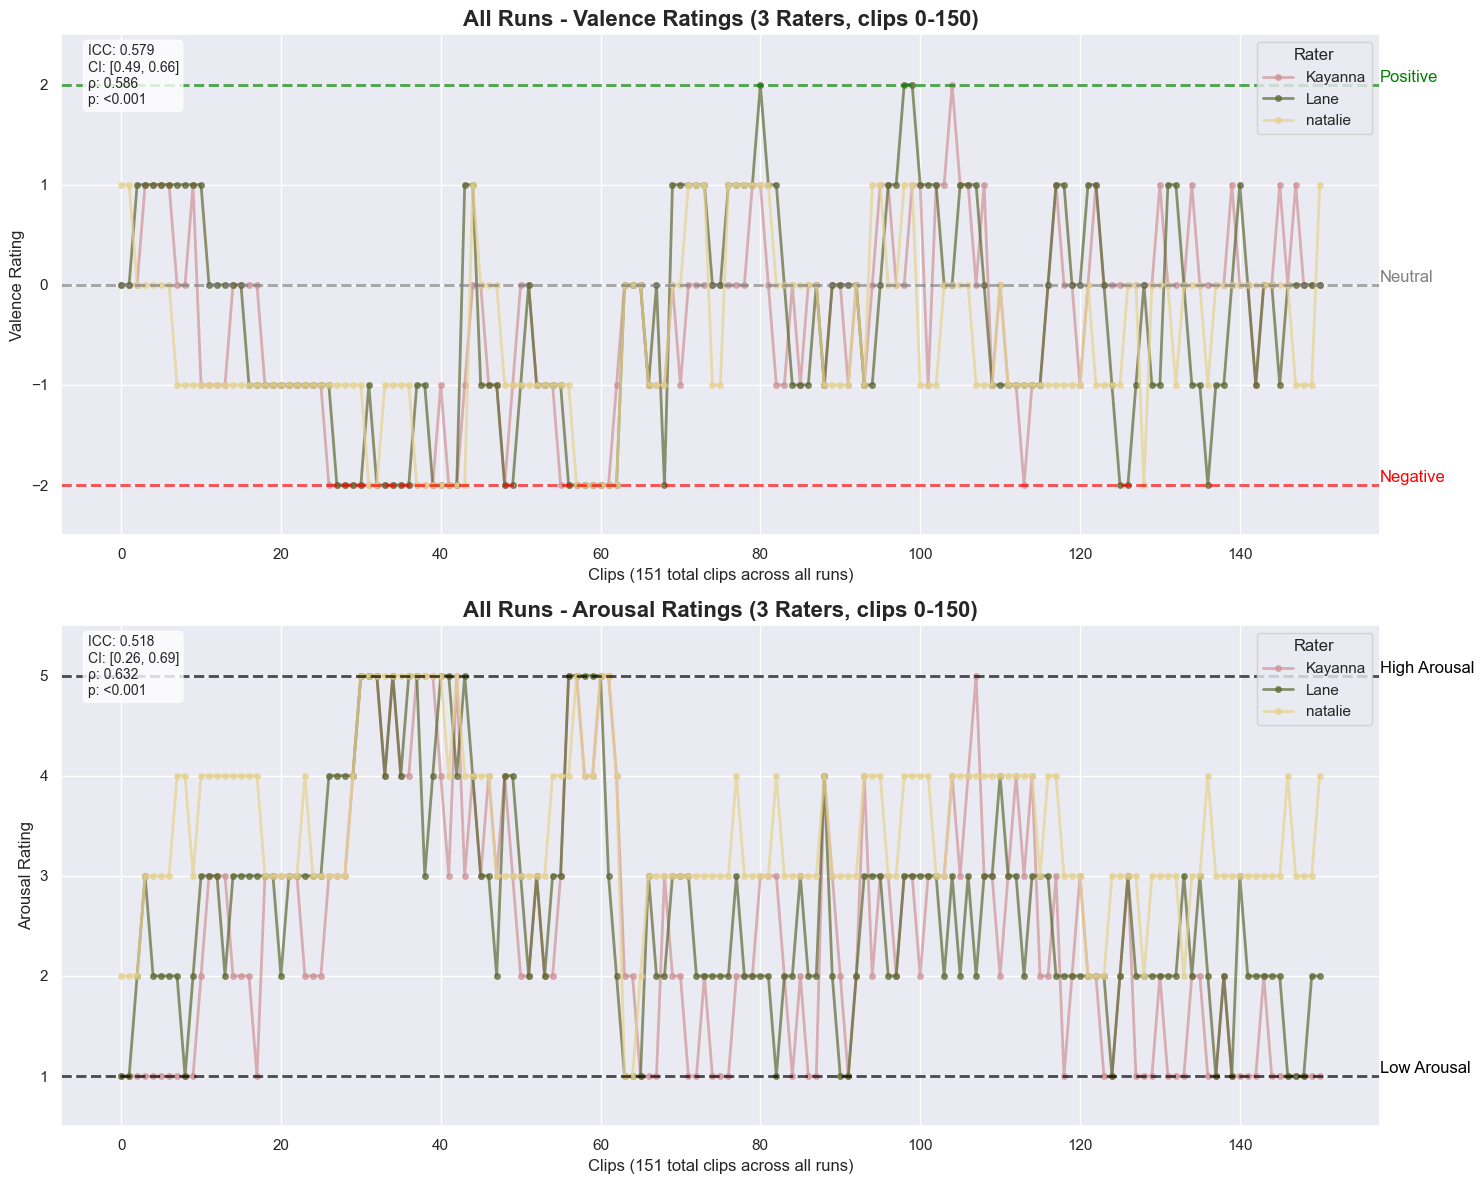


Visualization completed!


In [18]:
# Run plotting with all 3 raters
# Load the overall reliability results
reliability_results = pd.read_csv(OUT_DIR / "interrater_reliability_overall.csv")

# Find all rater annotation files
rater_files = sorted(list(ANNOT_DIR.glob("*.csv")))
rater_names = []
rater_dfs = []

for rater_file in rater_files:
    rater_name = rater_file.stem.split('(')[1].rstrip(')')
    rater_names.append(rater_name)
    df = pd.read_csv(rater_file)
    df = df.rename(columns={
        'valence': f'valence_{rater_name}',
        'arousal': f'arousal_{rater_name}'
    })
    rater_dfs.append(df[['index', f'valence_{rater_name}', f'arousal_{rater_name}']])

# Merge all raters
merged_df = rater_dfs[0]
for df in rater_dfs[1:]:
    merged_df = merged_df.merge(df, on='index', how='outer')

# Extract metadata
merged_df['episode'] = merged_df['index'].str.extract(r'S\d+E(\d+)').astype(int)
merged_df['run_number'] = merged_df['index'].str.extract(r'R(\d+)').astype(int)
merged_df['clip_number'] = merged_df['index'].str.extract(r'clip(\d+)').astype(int)

# FILTER: Only include clips up to clip0150
merged_df = merged_df[merged_df['clip_number'] <= 150].copy()
print(f"Plotting data filtered to clips 0-150 (N={len(merged_df)})")

valence_cols = [f'valence_{name}' for name in rater_names]
arousal_cols = [f'arousal_{name}' for name in rater_names]

# Sort and create sequential position
merged_df = merged_df.sort_values(['episode', 'run_number', 'clip_number'])
merged_df['sequential_position'] = range(len(merged_df))

print(f"\n{'='*60}")
print(f"Creating visualization for all runs combined")
print(f"{'='*60}")

# Make long format data
valence_long = merged_df.melt(
    id_vars=['sequential_position'], value_vars=valence_cols,
    var_name='rater', value_name='valence'
)
valence_long['rater'] = valence_long['rater'].str.replace('valence_', '')

arousal_long = merged_df.melt(
    id_vars=['sequential_position'], value_vars=arousal_cols,
    var_name='rater', value_name='arousal'
)
arousal_long['rater'] = arousal_long['rater'].str.replace('arousal_', '')

# Create plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

total_clips = len(merged_df)

# Valence plot
if not valence_long.empty:
    for i, rater in enumerate(sorted(valence_long['rater'].unique())):
        rater_data = valence_long[valence_long['rater'] == rater].sort_values('sequential_position')
        ax1.plot(rater_data['sequential_position'], rater_data['valence'], 
                color=colors[i % len(colors)], marker='o', markersize=4, linewidth=2, 
                alpha=0.7, label=rater)
    
    ax1.set_title(f'All Runs - Valence Ratings (3 Raters, clips 0-150)', fontsize=16, fontweight='bold')
    ax1.set_xlabel(f'Clips ({total_clips} total clips across all runs)', fontsize=12)
    ax1.set_ylabel('Valence Rating', fontsize=12)
    ax1.set_ylim(-2.5, 2.5)
    ax1.legend(title='Rater', loc='upper right')

    # Reference lines
    ax1.axhline(y=-2, color='red', linestyle='--', alpha=0.7, linewidth=2)
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.7, linewidth=2)
    ax1.axhline(y=2, color='green', linestyle='--', alpha=0.7, linewidth=2)
    
    x_right = ax1.get_xlim()[1]
    ax1.text(x_right, -2, 'Negative', ha='left', va='bottom', fontsize=12, color='red')
    ax1.text(x_right, 0, 'Neutral', ha='left', va='bottom', fontsize=12, color='gray')
    ax1.text(x_right, 2, 'Positive', ha='left', va='bottom', fontsize=12, color='green')
    
    # Add overall statistics
    overall_stats = reliability_results[reliability_results['Episode'] == 'All'].iloc[0]
    val_icc = overall_stats['Valence_ICC']
    val_ci_lower = overall_stats['Valence_ICC_CI_Lower']
    val_ci_upper = overall_stats['Valence_ICC_CI_Upper']
    val_spearman = overall_stats['Valence_Spearman_r']
    val_spearman_p = overall_stats['Valence_Spearman_pval']
    
    stats_text = []
    if pd.notna(val_icc):
        if abs(val_icc) < 0.001 and val_icc != 0:
            mantissa = val_icc / (10 ** int(np.floor(np.log10(abs(val_icc)))))
            exponent = int(np.floor(np.log10(abs(val_icc))))
            icc_str = f"{mantissa:.2f}×10$^{{{exponent}}}$"
        else:
            icc_str = f"{val_icc:.3f}"
        stats_text.append(f"ICC: {icc_str}")
        if pd.notna(val_ci_lower) and pd.notna(val_ci_upper):
            stats_text.append(f"CI: [{val_ci_lower:.2f}, {val_ci_upper:.2f}]")
    if pd.notna(val_spearman):
        if abs(val_spearman) < 0.001 and val_spearman != 0:
            mantissa = val_spearman / (10 ** int(np.floor(np.log10(abs(val_spearman)))))
            exponent = int(np.floor(np.log10(abs(val_spearman))))
            spearman_str = f"{mantissa:.2f}×10$^{{{exponent}}}$"
        else:
            spearman_str = f"{val_spearman:.3f}"
        stats_text.append(f"ρ: {spearman_str}")
        if pd.notna(val_spearman_p):
            p_str = f"{val_spearman_p:.3f}" if val_spearman_p >= 0.001 else "<0.001"
            stats_text.append(f"p: {p_str}")
    
    if stats_text:
        ax1.text(0.02, 0.98, '\n'.join(stats_text), transform=ax1.transAxes,
                fontsize=10, verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Arousal plot
if not arousal_long.empty:
    for i, rater in enumerate(sorted(arousal_long['rater'].unique())):
        rater_data = arousal_long[arousal_long['rater'] == rater].sort_values('sequential_position')
        ax2.plot(rater_data['sequential_position'], rater_data['arousal'], 
                color=colors[i % len(colors)], marker='o', markersize=4, linewidth=2, 
                alpha=0.7, label=rater)
    
    ax2.set_title(f'All Runs - Arousal Ratings (3 Raters, clips 0-150)', fontsize=16, fontweight='bold')
    ax2.set_xlabel(f'Clips ({total_clips} total clips across all runs)', fontsize=12)
    ax2.set_ylabel('Arousal Rating', fontsize=12)
    ax2.set_ylim(0.5, 5.5)
    ax2.legend(title='Rater', loc='upper right')

    # Reference lines
    ax2.axhline(y=1, color='black', linestyle='--', alpha=0.7, linewidth=2)
    ax2.axhline(y=5, color='black', linestyle='--', alpha=0.7, linewidth=2)
    
    x_right = ax2.get_xlim()[1]
    ax2.text(x_right, 1, 'Low Arousal', ha='left', va='bottom', fontsize=12, color='black')
    ax2.text(x_right, 5, 'High Arousal', ha='left', va='bottom', fontsize=12, color='black')
    
    # Add statistics
    aro_icc = overall_stats['Arousal_ICC']
    aro_ci_lower = overall_stats['Arousal_ICC_CI_Lower']
    aro_ci_upper = overall_stats['Arousal_ICC_CI_Upper']
    aro_spearman = overall_stats['Arousal_Spearman_r']
    aro_spearman_p = overall_stats['Arousal_Spearman_pval']
    
    stats_text = []
    if pd.notna(aro_icc):
        if abs(aro_icc) < 0.001 and aro_icc != 0:
            mantissa = aro_icc / (10 ** int(np.floor(np.log10(abs(aro_icc)))))
            exponent = int(np.floor(np.log10(abs(aro_icc))))
            icc_str = f"{mantissa:.2f}×10$^{{{exponent}}}$"
        else:
            icc_str = f"{aro_icc:.3f}"
        stats_text.append(f"ICC: {icc_str}")
        if pd.notna(aro_ci_lower) and pd.notna(aro_ci_upper):
            stats_text.append(f"CI: [{aro_ci_lower:.2f}, {aro_ci_upper:.2f}]")
    if pd.notna(aro_spearman):
        if abs(aro_spearman) < 0.001 and aro_spearman != 0:
            mantissa = aro_spearman / (10 ** int(np.floor(np.log10(abs(aro_spearman)))))
            exponent = int(np.floor(np.log10(abs(aro_spearman))))
            spearman_str = f"{mantissa:.2f}×10$^{{{exponent}}}$"
        else:
            spearman_str = f"{aro_spearman:.3f}"
        stats_text.append(f"ρ: {spearman_str}")
        if pd.notna(aro_spearman_p):
            p_str = f"{aro_spearman_p:.3f}" if aro_spearman_p >= 0.001 else "<0.001"
            stats_text.append(f"p: {p_str}")
    
    if stats_text:
        ax2.text(0.02, 0.98, '\n'.join(stats_text), transform=ax2.transAxes,
                fontsize=10, verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()

# Save figure
figure_filename = f"all_runs_emotion_ratings.png"
figure_path = FIGURES_DIR / figure_filename
fig.savefig(figure_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"📁 Figure saved: {figure_path}")

plt.show()

print(f"\n{'='*60}")
print("Visualization completed!")
print(f"{'='*60}")

Plotting data filtered to clips 0-150 (N=151)

Creating plot for Episode 1 Run 1
    📁 Figure saved: dset/derivatives/figures/episode_01_run_01_emotion_ratings.png
    📁 Figure saved: dset/derivatives/figures/episode_01_run_01_emotion_ratings.png


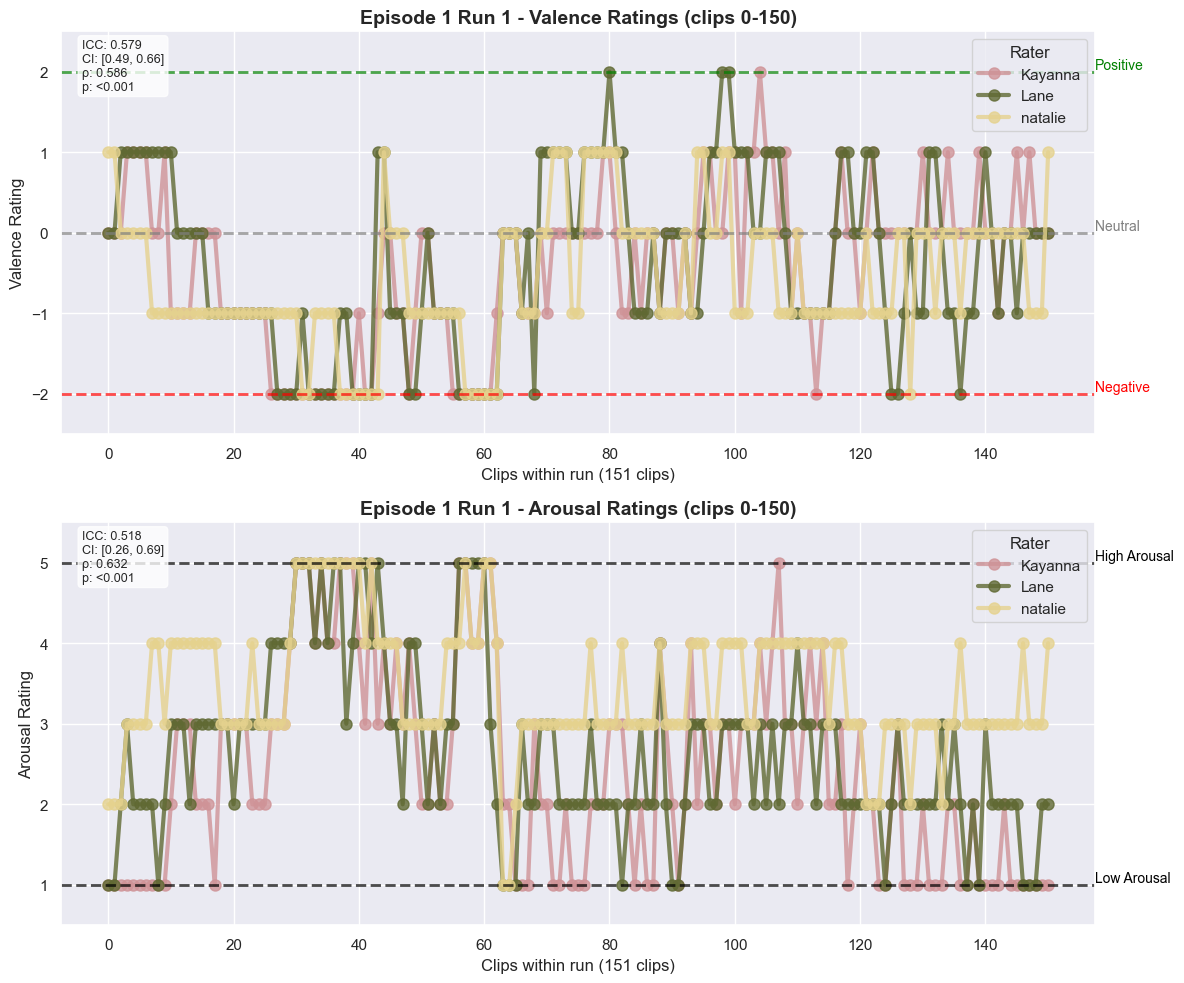


All individual run plots completed!


In [19]:
# Individual Run Plotting - Save each run as separate figure with 3 raters
# Load the run-level reliability results
run_reliability_results = pd.read_csv(OUT_DIR / "interrater_reliability_by_run.csv")

# Load rater files
rater_files = sorted(list(ANNOT_DIR.glob("*.csv")))
rater_names = []
rater_dfs = []

for rater_file in rater_files:
    rater_name = rater_file.stem.split('(')[1].rstrip(')')
    rater_names.append(rater_name)
    df = pd.read_csv(rater_file)
    df = df.rename(columns={
        'valence': f'valence_{rater_name}',
        'arousal': f'arousal_{rater_name}'
    })
    rater_dfs.append(df[['index', f'valence_{rater_name}', f'arousal_{rater_name}']])

# Merge all raters
merged_df = rater_dfs[0]
for df in rater_dfs[1:]:
    merged_df = merged_df.merge(df, on='index', how='outer')

# Extract metadata
merged_df['episode'] = merged_df['index'].str.extract(r'S\d+E(\d+)').astype(int)
merged_df['run_number'] = merged_df['index'].str.extract(r'R(\d+)').astype(int)
merged_df['clip_number'] = merged_df['index'].str.extract(r'clip(\d+)').astype(int)

# FILTER: Only include clips up to clip0150
merged_df = merged_df[merged_df['clip_number'] <= 150].copy()
print(f"Plotting data filtered to clips 0-150 (N={len(merged_df)})")

valence_cols = [f'valence_{name}' for name in rater_names]
arousal_cols = [f'arousal_{name}' for name in rater_names]

# Process each run
unique_runs = merged_df.groupby(['episode', 'run_number'])

for (ep_num, run_num), run_data in unique_runs:
    print(f"\n{'='*60}")
    print(f"Creating plot for Episode {ep_num} Run {run_num}")
    print(f"{'='*60}")
    
    run_data = run_data.sort_values('clip_number').copy()
    run_data['run_position'] = range(len(run_data))
    
    # Make long format data
    valence_long_run = run_data.melt(
        id_vars=['run_position'], value_vars=valence_cols,
        var_name='rater', value_name='valence'
    )
    valence_long_run['rater'] = valence_long_run['rater'].str.replace('valence_', '')

    arousal_long_run = run_data.melt(
        id_vars=['run_position'], value_vars=arousal_cols,
        var_name='rater', value_name='arousal'
    )
    arousal_long_run['rater'] = arousal_long_run['rater'].str.replace('arousal_', '')

    # Create plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Valence plot
    if not valence_long_run.empty:
        for i, rater in enumerate(sorted(valence_long_run['rater'].unique())):
            rater_data = valence_long_run[valence_long_run['rater'] == rater].sort_values('run_position')
            ax1.plot(rater_data['run_position'], rater_data['valence'], 
                    color=colors[i % len(colors)], marker='o', markersize=8, linewidth=3, 
                    alpha=0.8, label=rater)
        
        ax1.set_title(f'Episode {ep_num} Run {run_num} - Valence Ratings (clips 0-150)', fontsize=14, fontweight='bold')
        ax1.set_xlabel(f'Clips within run ({len(run_data)} clips)', fontsize=12)
        ax1.set_ylabel('Valence Rating', fontsize=12)
        ax1.set_ylim(-2.5, 2.5)
        ax1.legend(title='Rater', loc='upper right')

        # Reference lines
        ax1.axhline(y=-2, color='red', linestyle='--', alpha=0.7, linewidth=2)
        ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.7, linewidth=2)
        ax1.axhline(y=2, color='green', linestyle='--', alpha=0.7, linewidth=2)
        
        x_right = ax1.get_xlim()[1]
        ax1.text(x_right, -2, 'Negative', ha='left', va='bottom', fontsize=10, color='red')
        ax1.text(x_right, 0, 'Neutral', ha='left', va='bottom', fontsize=10, color='gray')
        ax1.text(x_right, 2, 'Positive', ha='left', va='bottom', fontsize=10, color='green')
        
        # Add statistics
        run_stats = run_reliability_results[
            (run_reliability_results['Episode'] == ep_num) & 
            (run_reliability_results['Run'] == run_num)
        ]
        if not run_stats.empty:
            run_stat = run_stats.iloc[0]
            val_icc = run_stat['Valence_ICC']
            val_ci_lower = run_stat['Valence_ICC_CI_Lower']
            val_ci_upper = run_stat['Valence_ICC_CI_Upper']
            val_spearman = run_stat['Valence_Spearman_r']
            val_spearman_p = run_stat['Valence_Spearman_pval']
            
            stats_text = []
            if pd.notna(val_icc):
                if abs(val_icc) < 0.001 and val_icc != 0:
                    mantissa = val_icc / (10 ** int(np.floor(np.log10(abs(val_icc)))))
                    exponent = int(np.floor(np.log10(abs(val_icc))))
                    icc_str = f"{mantissa:.2f}×10$^{{{exponent}}}$"
                else:
                    icc_str = f"{val_icc:.3f}"
                stats_text.append(f"ICC: {icc_str}")
                if pd.notna(val_ci_lower) and pd.notna(val_ci_upper):
                    stats_text.append(f"CI: [{val_ci_lower:.2f}, {val_ci_upper:.2f}]")
            if pd.notna(val_spearman):
                if abs(val_spearman) < 0.001 and val_spearman != 0:
                    mantissa = val_spearman / (10 ** int(np.floor(np.log10(abs(val_spearman)))))
                    exponent = int(np.floor(np.log10(abs(val_spearman))))
                    spearman_str = f"{mantissa:.2f}×10$^{{{exponent}}}$"
                else:
                    spearman_str = f"{val_spearman:.3f}"
                stats_text.append(f"ρ: {spearman_str}")
                if pd.notna(val_spearman_p):
                    p_str = f"{val_spearman_p:.3f}" if val_spearman_p >= 0.001 else "<0.001"
                    stats_text.append(f"p: {p_str}")
            
            if stats_text:
                ax1.text(0.02, 0.98, '\n'.join(stats_text), transform=ax1.transAxes,
                        fontsize=9, verticalalignment='top', horizontalalignment='left',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # Arousal plot
    if not arousal_long_run.empty:
        for i, rater in enumerate(sorted(arousal_long_run['rater'].unique())):
            rater_data = arousal_long_run[arousal_long_run['rater'] == rater].sort_values('run_position')
            ax2.plot(rater_data['run_position'], rater_data['arousal'], 
                    color=colors[i % len(colors)], marker='o', markersize=8, linewidth=3, 
                    alpha=0.8, label=rater)
        
        ax2.set_title(f'Episode {ep_num} Run {run_num} - Arousal Ratings (clips 0-150)', fontsize=14, fontweight='bold')
        ax2.set_xlabel(f'Clips within run ({len(run_data)} clips)', fontsize=12)
        ax2.set_ylabel('Arousal Rating', fontsize=12)
        ax2.set_ylim(0.5, 5.5)
        ax2.legend(title='Rater', loc='upper right')

        # Reference lines
        ax2.axhline(y=1, color='black', linestyle='--', alpha=0.7, linewidth=2)
        ax2.axhline(y=5, color='black', linestyle='--', alpha=0.7, linewidth=2)
        
        x_right = ax2.get_xlim()[1]
        ax2.text(x_right, 1, 'Low Arousal', ha='left', va='bottom', fontsize=10, color='black')
        ax2.text(x_right, 5, 'High Arousal', ha='left', va='bottom', fontsize=10, color='black')
        
        # Add statistics
        if not run_stats.empty:
            aro_icc = run_stat['Arousal_ICC']
            aro_ci_lower = run_stat['Arousal_ICC_CI_Lower']
            aro_ci_upper = run_stat['Arousal_ICC_CI_Upper']
            aro_spearman = run_stat['Arousal_Spearman_r']
            aro_spearman_p = run_stat['Arousal_Spearman_pval']
            
            stats_text = []
            if pd.notna(aro_icc):
                if abs(aro_icc) < 0.001 and aro_icc != 0:
                    mantissa = aro_icc / (10 ** int(np.floor(np.log10(abs(aro_icc)))))
                    exponent = int(np.floor(np.log10(abs(aro_icc))))
                    icc_str = f"{mantissa:.2f}×10$^{{{exponent}}}$"
                else:
                    icc_str = f"{aro_icc:.3f}"
                stats_text.append(f"ICC: {icc_str}")
                if pd.notna(aro_ci_lower) and pd.notna(aro_ci_upper):
                    stats_text.append(f"CI: [{aro_ci_lower:.2f}, {aro_ci_upper:.2f}]")
            if pd.notna(aro_spearman):
                if abs(aro_spearman) < 0.001 and aro_spearman != 0:
                    mantissa = aro_spearman / (10 ** int(np.floor(np.log10(abs(aro_spearman)))))
                    exponent = int(np.floor(np.log10(abs(aro_spearman))))
                    spearman_str = f"{mantissa:.2f}×10$^{{{exponent}}}$"
                else:
                    spearman_str = f"{aro_spearman:.3f}"
                stats_text.append(f"ρ: {spearman_str}")
                if pd.notna(aro_spearman_p):
                    p_str = f"{aro_spearman_p:.3f}" if aro_spearman_p >= 0.001 else "<0.001"
                    stats_text.append(f"p: {p_str}")
            
            if stats_text:
                ax2.text(0.02, 0.98, '\n'.join(stats_text), transform=ax2.transAxes,
                        fontsize=9, verticalalignment='top', horizontalalignment='left',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    plt.tight_layout()
    
    # Save figure
    figure_filename = f"episode_{ep_num:02d}_run_{run_num:02d}_emotion_ratings.png"
    figure_path = FIGURES_DIR / figure_filename
    fig.savefig(figure_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"    📁 Figure saved: {figure_path}")
    
    plt.show()

print(f"\n{'='*60}")
print("All individual run plots completed!")
print(f"{'='*60}")

In [20]:
# Save all figures in one PDF (disabled - uncomment to enable)
# This cell generates a comprehensive PDF with all plots
# Uncomment the code below if you want to generate the PDF

# from matplotlib.backends.backend_pdf import PdfPages
# import matplotlib.pyplot as plt

# pdf_filename = FIGURES_DIR / "all_emotion_ratings_3raters.pdf"

# with PdfPages(pdf_filename) as pdf:
#     print(f"Creating comprehensive PDF: {pdf_filename}")
#     # ... (similar structure to individual plots but saving to PDF)
    
print("PDF generation cell - currently disabled. Uncomment to enable.")

PDF generation cell - currently disabled. Uncomment to enable.


In [21]:
# Average ratings across all 3 raters and save combined files

# Load rater files
rater_files = sorted(list(ANNOT_DIR.glob("*.csv")))
rater_names = []
rater_dfs = []

print(f"\n{'='*60}")
print("Creating averaged rating files")
print(f"{'='*60}")

for rater_file in rater_files:
    rater_name = rater_file.stem.split('(')[1].rstrip(')')
    rater_names.append(rater_name)
    df = pd.read_csv(rater_file)
    df = df.rename(columns={
        'valence': f'valence_{rater_name}',
        'arousal': f'arousal_{rater_name}'
    })
    rater_dfs.append(df[['index', f'valence_{rater_name}', f'arousal_{rater_name}']])

# Merge all raters
merged_df = rater_dfs[0]
for df in rater_dfs[1:]:
    merged_df = merged_df.merge(df, on='index', how='outer')

# Extract metadata
merged_df['episode'] = merged_df['index'].str.extract(r'S\d+E(\d+)').astype(int)
merged_df['run_number'] = merged_df['index'].str.extract(r'R(\d+)').astype(int)
merged_df['clip_number'] = merged_df['index'].str.extract(r'clip(\d+)').astype(int)
merged_df['run'] = merged_df['index'].str.extract(r'(S\d+E\d+R\d+)')[0]

# FILTER: Only include clips up to clip0150
merged_df = merged_df[merged_df['clip_number'] <= 150].copy()
print(f"Averaging data filtered to clips 0-150 (N={len(merged_df)})")

valence_cols = [f'valence_{name}' for name in rater_names]
arousal_cols = [f'arousal_{name}' for name in rater_names]

# Average across all raters
merged_df['valence'] = merged_df[valence_cols].mean(axis=1)
merged_df['arousal'] = merged_df[arousal_cols].mean(axis=1)

# Create output dataframe
output_df = merged_df[['index', 'valence', 'arousal', 'run']].copy()

print(f"Total clips: {len(output_df)}")
print(f"Averaged across {len(rater_names)} raters: {', '.join(rater_names)}")
print(output_df.head(10))

# Save single combined file
combined_filename = "S01E01R01_avg.csv"
output_df.to_csv(OUT_DIR / combined_filename, index=False)

print(f"\n✅ Saved combined file: {OUT_DIR / combined_filename}")
print(f"{'='*60}")


Creating averaged rating files
Averaging data filtered to clips 0-150 (N=151)
Total clips: 151
Averaged across 3 raters: Kayanna, Lane, natalie
                index   valence   arousal        run
0  S01E01R01_clip0000  0.333333  1.333333  S01E01R01
1  S01E01R01_clip0001  0.333333  1.333333  S01E01R01
2  S01E01R01_clip0002  0.333333  1.666667  S01E01R01
3  S01E01R01_clip0003  0.666667  2.333333  S01E01R01
4  S01E01R01_clip0004  0.666667  2.000000  S01E01R01
5  S01E01R01_clip0005  0.666667  2.000000  S01E01R01
6  S01E01R01_clip0006  0.666667  2.000000  S01E01R01
7  S01E01R01_clip0007  0.000000  2.333333  S01E01R01
8  S01E01R01_clip0008  0.000000  2.000000  S01E01R01
9  S01E01R01_clip0009  0.333333  2.000000  S01E01R01

✅ Saved combined file: dset/derivatives/caps/interrater/S01E01R01_avg.csv
